# <u>Lab Two - Classification</u>

Authors:  Muskaan Mahes, Chloe Prowse, Aayush Dalal, Nino Castellano

In [1]:
# Necessary imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## 1) <u> Data Preparation </u>

### Define and Prepare Class Variables

The Student Placement Dataset from Kaggle was collected and analyzed to determine whether students’ results were sufficient to obtain a job offer. The dataset contained over 50,000 records consisting of academic, technical, and soft-skill attributes that can influence the outcome of being placed or not. <b>(This is our primary Classification Task #1)</b> Therefore, the primary purpose of the dataset is to help students, educational institutions, career centers understand which factors are crucial for achieving a successful placement outcome. 

We previously used this data to analyze and explore the relationships between students’ key features and their placement outcome to identify important insights. We then built and evaluated two classification models (SVM and Logistic Regression) to predict a student's placement status based on various academic, technical, and personal attributes. Now our objective is to take it a step further by training and evaluating different classification models for our existing classification task, Placement Status, while also training/evaluating those same models on a different classification task we can come up with from this data.

For example, as a <b>Secondary Classification Task #2 </b> aligned with our broader goal of understanding the factors that contribute to long-term career success, we could classify a student’s likelihood of securing an internship based on their current academic, technical, and personal attributes. Predicting internship attainment is particularly meaningful because internships often serve as a critical stepping stone toward full-time employment. By modeling internship probability, we can evaluate where a student currently stands in their professional development journey and identify areas for improvement. Since even a single internship can significantly increase the likelihood of receiving a full-time offer later, this secondary task provides both practical and predictive value alongside our primary placement classification objective.

Summarizing Clasification Tasks:

- <b>Placement Outcome (Yes or No) </b>
- <b>Internship Placement (Yes or No) </b>

Together, these two classification tasks create a developmental pathway: predicting internship probability drives short-term skill adjustments that increase immediate opportunities, and those strengthened skills directly feed into improved placement outcomes, ultimately supporting long-term full-time career success.

In [2]:
#loading dataset
df = pd.read_csv("full_dataset.csv")
print(df.shape)
df.head()

(50000, 15)


,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


### Describe Final Dataset

Using our previously preprocessed from earlier labs which has already been cleaned, and verified to contain no missing values; the data is ready preprocessing using encoding and scaling and then for model training and testing. The only additional step required is to create a new encoded target variable, <b>Internship Placement</b>, derived from the <b>Internships</b> feature. Students with at least one internship will be labeled <b>Yes</b>, while those with none will be labeled <b>No</b>.

In [3]:
#dropping ID Because it is not useful for the model
df = df.drop(columns=["Student_ID"], errors='ignore')

# Create Internship Placement binary target variable
df["Internship_Placement"] = np.where(df["Internships"] >= 1, "Yes", "No")

#identifying numeric and categorical columns
numeric_columns = df.select_dtypes(include=[np.number]).columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Verify the identified columns
print("Numeric Columns:", len(numeric_columns))
print(numeric_columns)
print("Categorical Columns:", len(categorical_columns))
print(categorical_columns)

Numeric Columns: 10
Index(['Age', 'CGPA', 'Internships', 'Projects', 'Coding_Skills',
       'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating',
       'Certifications', 'Backlogs'],
      dtype='object')
Categorical Columns: 5
Index(['Gender', 'Degree', 'Branch', 'Placement_Status',
       'Internship_Placement'],
      dtype='object')


In [4]:
print(df.shape)
df.head()

(50000, 15)


,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status,Internship_Placement
0,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed,No
1,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed,Yes
2,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed,Yes
3,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed,Yes
4,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed,Yes


## 2) <u> Modeling and Evaluation </u>

### Choosing and Explaining Evaluation Metrics

*Nino's Task: To Ellaborate more on Why we are using Precision for Evaluation*

### Method for Splitting Train and Test Sets

*Nino's Task: Explain the Splitting Criteria and Stratefied Fold*

In [5]:
# Encoding Placement_Status (Task 1)
le_task1 = LabelEncoder()
df["Placement_Status"] = le_task1.fit_transform(df["Placement_Status"])

# Encoding Internship_Placement (Task 2)
le_task2 = LabelEncoder()
df["Internship_Placement"] = le_task2.fit_transform(df["Internship_Placement"])

In [6]:
df.head()

,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status,Internship_Placement
0,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,0,0
1,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,0,1
2,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,0,1
3,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,1,1
4,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,1,1


In [7]:
# Getting Test and Train Split for Task 1: Placement Status Classification
X_task1 = df.drop(columns=["Placement_Status", "Internship_Placement"])
y_task1 = df["Placement_Status"]

# Identify feature types AFTER dropping targets
numeric_columns_task1 = X_task1.select_dtypes(include=np.number).columns
categorical_columns_task1 = X_task1.select_dtypes(include="object").columns

# Preprocessor for Task 1
preprocessor_task1 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns_task1),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_columns_task1)
    ]
)

# Train Test Split
X_train_task1, X_test_task1, y_train_task1, y_test_task1 = train_test_split(
    X_task1,
    y_task1,
    test_size=0.3,
    random_state=42,
    stratify=y_task1
)

# Fit ONLY on train
X_train_task1 = preprocessor_task1.fit_transform(X_train_task1)
X_test_task1 = preprocessor_task1.transform(X_test_task1)

In [8]:
# Getting Test and Train Data for Task 2: Internship Placement Classification
X_task2 = df.drop(columns=[
    "Internship_Placement", # target variable for Task 2
    "Internships",          # used to create target
    "Placement_Status"      # logically happens after internship
])

y_task2 = df["Internship_Placement"]

X_train_task2, X_test_task2, y_train_task2, y_test_task2 = train_test_split(
    X_task2, y_task2,
    test_size=0.3,
    random_state=42,
    stratify=y_task2
)

# IMPORTANT:
# Recreate column lists for Task 2 (since we dropped features)

numeric_columns_task2 = X_task2.select_dtypes(include=np.number).columns
categorical_columns_task2 = X_task2.select_dtypes(include="object").columns

preprocessor_task2 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns_task2),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_columns_task2)
    ]
)

X_train_task2 = preprocessor_task2.fit_transform(X_train_task2)
X_test_task2 = preprocessor_task2.transform(X_test_task2)

In [9]:
# Final Ready-to-Use Data
print("TASK 1 Ready Shapes:")
print(X_train_task1.shape, X_test_task1.shape)

print("\nTASK 2 Ready Shapes:")
print(X_train_task2.shape, X_test_task2.shape)

TASK 1 Ready Shapes:
(35000, 18) (15000, 18)

TASK 2 Ready Shapes:
(35000, 17) (15000, 17)


<u>Note on how to Plug and Play Test and Train Sets into Models</u>

Task 1 Train and Test Sets (Placement Status):
X_train_task1, X_test_task1, y_train_task1, y_test_task1

Task 2 Train and Test Sets (Internship Placement):
X_train_task2, X_test_task2, y_train_task2, y_test_task2

Instructions on How to Use:

1. Initialize model
2. Fit on train
3. Predict on test
4. Evaluate

Example Classifier for Task 1:

Initialize

- rf = RandomForestClassifier(random_state=42)

Train

- rf.fit(X_train_task1, y_train_task1)

Predict on test set

- y_pred_task1 = rf.predict(X_test_task1)

Evaluate

- print("Accuracy:", accuracy_score(y_test_task1, y_pred_task1))
- print(classification_report(y_test_task1, y_pred_task1))



### Three Different Classification/Regression Models

SVM Classifier

In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("full_dataset.csv")

# Quick check
df.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


In [4]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np


# Target variable
y = df['Placement_Status']

# Features
X = df.drop(['Placement_Status', 'Student_ID'], axis=1)

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)
# Initialize SVM model
svm_model = SVC(kernel='rbf', C=1, gamma='scale')

# Use Stratified 10-fold Cross Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Evaluate with cross validation
accuracy_scores = cross_val_score(svm_model, X, y, cv=cv, scoring='accuracy')

print("Cross Validation Accuracy Scores:", accuracy_scores)
print("Average Accuracy:", np.mean(accuracy_scores))

Cross Validation Accuracy Scores: [0.8724 0.8728 0.8774 0.8692 0.8718 0.8896 0.8778 0.8808 0.8796 0.8782]
Average Accuracy: 0.8769600000000001


In [6]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train on training data
svm_model.fit(X_train, y_train)

# Predict on test data
y_pred_svm = svm_model.predict(X_test)

# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

Accuracy: 0.8744

Confusion Matrix:
 [[5793  582]
 [ 674 2951]]

Classification Report:
               precision    recall  f1-score   support

  Not Placed       0.90      0.91      0.90      6375
      Placed       0.84      0.81      0.82      3625

    accuracy                           0.87     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.87      0.87     10000



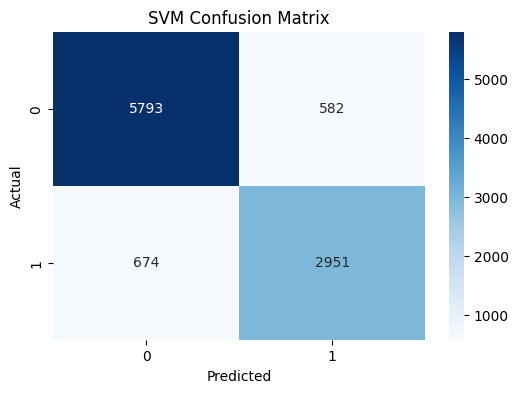

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Analyze Model Results Using Choosen Evaluation Metric

The Support Vector Machine (SVM) classifier was evaluated using several classification metrics including accuracy, precision, recall, and F1-score. These metrics were chosen because they provide a comprehensive evaluation of classification performance, especially when dealing with imbalanced datasets.

The model achieved an overall accuracy of 87.44%, indicating that the classifier correctly predicted the placement outcome for the majority of students in the dataset. Accuracy provides a general understanding of model performance by measuring the proportion of correct predictions out of all predictions.

To further analyze the results, the confusion matrix and classification report were examined. The confusion matrix showed that 5793 students were correctly classified as Not Placed and 2951 students were correctly classified as Placed. However, the model incorrectly predicted 582 students as Placed when they were actually Not Placed, and 674 students as Not Placed when they were actually Placed.

Precision, recall, and F1-scores provide additional insights into model performance. For the Not Placed class, the model achieved a precision of 0.90 and recall of 0.91, indicating strong performance in identifying students who were not placed. For the Placed class, the model achieved a precision of 0.84 and recall of 0.81, showing that the model is still effective but slightly less accurate for predicting students who were placed.

Overall, the SVM classifier demonstrates strong predictive performance and generalizes well to unseen data.

### Discuss Advantages of Each Model on Each Classification/Regression Task

One advantage of using a Support Vector Machine classifier is its ability to handle high-dimensional data effectively. In this dataset, multiple student attributes such as CGPA, internships, projects, coding skills, and aptitude scores contribute to predicting placement outcomes. SVM works well in such scenarios because it identifies an optimal decision boundary that maximizes the separation between classes.

Another advantage of SVM is its ability to model nonlinear relationships through the use of kernel functions. In this analysis, the Radial Basis Function (RBF) kernel was used, allowing the model to capture complex relationships between student attributes and placement outcomes that may not be linearly separable.

SVM also tends to perform well when the dataset has a clear margin of separation between classes, which appears to be the case in this dataset. The strong accuracy and balanced precision and recall scores suggest that the model is able to effectively distinguish between students who are placed and those who are not placed.

Overall, SVM provides a robust classification approach that balances predictive accuracy and generalization ability.

### Which Attributes are Most Important for each Classification Task

Although SVM models do not inherently provide feature importance scores like decision tree–based models, the influence of features can still be inferred based on the variables included in the model and their relationship to the target variable.

In this dataset, several attributes likely play a significant role in predicting student placement outcomes. Features such as CGPA, number of internships, number of projects, coding skills, and aptitude test scores directly reflect a student’s technical capability and academic performance. These attributes are expected to strongly influence whether a student receives a job placement.

Additionally, communication skills and soft skills ratings may contribute to placement outcomes because employers often evaluate both technical ability and interpersonal skills during hiring processes.

Finally, variables such as backlogs and certifications may also influence placement outcomes. Students with fewer academic backlogs and more certifications may appear more competitive to employers.

Overall, the most important attributes for the classification task appear to be those that measure academic performance, technical ability, and professional experience, as these factors are directly related to a student’s readiness for employment.

## 3) <u> Deployment </u>

### Usefulness of Model to Interested Parties 

## 4) <u> Exceptional Work </u>

### Additional Model or Hyperparameter Tuning Via Grid Search